# STAR Protocol

### Paper code
Load data and anlysis

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
%load_ext autoreload
%autoreload 2
from photom import Photom
from photom import Photom, import_metadata, add_zt_columns


Example with a single file. It reads the data from a binary ppd file and preprocesses the data.

In [3]:
photom = Photom("/Users/hakan/Library/CloudStorage/Dropbox/Amelia/BIDMC-Harvard/Circadian/STAR-Protocol/020219-2-2019-09-17-161002.ppd",
                signal_channel = "analog_1",
                control_channel = "analog_2",
                low_pass = 5,           # low_pass
                high_pass = 0.0001,     # high_pass
                preprocess = True,        # Preprocess the data
                median_filter = 21, 
                downsample_factor = 2,   # Downsample from 10 Hz to 5 Hz 
                downsample_method = "mean",
                bleach_correct = True,
                motion_correct = True,
                normalization = "z-score",
                timeseries = False,
                as_df = True
                )


Preprocessing data...
Data preprocessed. See processing_history for details.
Contructing the DataFrame...
DataFrame is ready and accessible as Photom.data_df


KeyError: 'ZT'

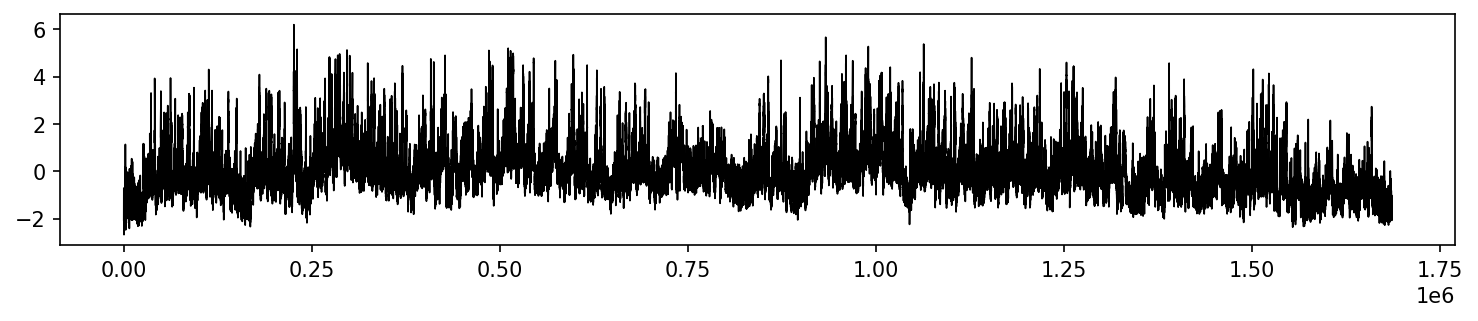

In [4]:
# photom.data_df
fig, ax = plt.subplots(figsize=(12,2), dpi=150)

# df = photom.data_df.query('index >= @begin_time & index <= @end_time')

ax.plot(photom.data_df.index, photom.data_df['signal_norm'], color="black", lw=0.8)
# ax.plot(photom.data_df.index, photom.data_df['control_norm'], color="tomato")

xticks = np.array([df.iloc[0].name for (zt, day), df in photom.data_df.groupby(['ZT','day']) if zt in [0,12]])
xticklabels = np.array([f'Day {day} ZT{zt}' for (zt, day), df in photom.data_df.groupby(['ZT','day']) if zt in [0,12]])
ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels, rotation=45, ha='right')

for a, b in np.sort(xticks).reshape(-1,2):
    ax.fill_between([a,b], -3, 7, color="lightgray", alpha=0.5, lw=0)


Example with multiple files. It reads the data from a binary ppd file and preprocesses the data.

In [ ]:
%load_ext autoreload
%autoreload 2
from photom import Photom
from photom import Photom, import_metadata, import_ppd, add_zt_columns


In [ ]:
photom = Photom(["/Users/hakan/Library/CloudStorage/Dropbox/Amelia/BIDMC-Harvard/Circadian/STAR-Protocol/data/020219-2-2019-09-20-080200.ppd",
                 "/Users/hakan/Library/CloudStorage/Dropbox/Amelia/BIDMC-Harvard/Circadian/STAR-Protocol/data/020219-2-2019-09-17-161002.ppd"],
                signal_channel = "analog_1",
                control_channel = "analog_2",
                low_pass = 5,           # low_pass
                high_pass = 0.0001,     # high_pass
                preprocess = True,        # Preprocess the data
                median_filter = 21, 
                # downsample_factor = 2,   # Downsample from 10 Hz to 5 Hz 
                # downsample_method = "mean",
                bleach_correct = True,
                motion_correct = True,
                normalization = "z-score",
                timeseries = True,
                as_df = True
                )


In [ ]:
photom.data_df['signal'].plot()


In [ ]:
photom.save_processing_history(base_dir)

In [ ]:
file_paths = ["/Users/hakan/Library/CloudStorage/Dropbox/Amelia/Circadian/STAR-Protocol/data/020219-2-2019-09-20-080200.ppd",
              "/Users/hakan/Library/CloudStorage/Dropbox/Amelia/Circadian/STAR-Protocol/data/020219-2-2019-09-17-161002.ppd"]


In [ ]:


file_paths = ["/Users/hakan/Library/CloudStorage/Dropbox/Amelia/Circadian/STAR-Protocol/data/020219-2-2019-09-20-080200.ppd",
              "/Users/hakan/Library/CloudStorage/Dropbox/Amelia/Circadian/STAR-Protocol/data/020219-2-2019-09-17-161002.ppd"]

allow_mixed_modes = False
allow_mixed_subjects = False

from typing import List, Dict
import numpy as np

def _combine_files(file_paths: List[str],
                   allow_mixed_modes: bool = False, 
                   allow_mixed_subjects: bool = False) -> Dict:
    
    metadata_temp = import_metadata(file_paths[0])  # Load metadata from first file

    Data, Metadata = [], []
    for i, file_path in enumerate(file_paths):
        data, metadata = import_ppd(file_path)
        metadata['session_id'] = i + 1  # Assign session ID
        
        # Ensure consistency across recordings
        if metadata_temp['sampling_rate'] != metadata['sampling_rate']:
            raise ValueError("Concatenating recordings with different sampling rates is not allowed. "
                             "Load them individually and downsample to the same rate before concatenation.")
        if not allow_mixed_subjects and metadata_temp['subject_ID'] != metadata['subject_ID']:
            raise ValueError("You are trying to concatenate recordings from multiple subjects. "
                             "If intentional, set allow_mixed_subjects=True.")
        if not allow_mixed_modes and metadata_temp['mode'] != metadata['mode']:
            raise ValueError("You are trying to concatenate recordings with different modes. "
                             "If intentional, set allow_mixed_modes=True.")

        Data.append(data)
        Metadata.append(metadata)

    # Combine metadata
    combined_metadata = {key: [d[key] for d in Metadata] for key in Metadata[0]}
    combined_metadata['version'] = np.unique(combined_metadata['version'])[0]
    combined_metadata['sampling_rate'] = np.unique(combined_metadata['sampling_rate'])[0]

    if not allow_mixed_subjects:
        combined_metadata['subject_ID'] = np.unique(combined_metadata['subject_ID'])[0]
    if not allow_mixed_modes:
        combined_metadata['mode'] = np.unique(combined_metadata['mode'])[0]

    # Find shared keys across all data dictionaries
    shared_keys = set(Data[0].keys()).intersection(*(d.keys() for d in Data[1:]))

    # Combine data using shared keys
    combined_data = {key: np.concatenate([d[key] for d in Data if key in d]) for key in shared_keys}

    return combined_data, combined_metadata



In [ ]:
    keys_list = set(Data[0].keys())
    for data_dict in Data[1:]:
        keys_list.intersection_update(data_dict.keys())

    for key in keys_list:
        for i, data_dict in enumerate(Data):
            if key in data_dict:
                combined_data[key] = np.concatenate([combined_data[key], data_dict[key]])


Plot the results.

In [ ]:
plot_recording(
    photom,
    signals = 'signal_norm',
    start_time = None,
    end_time = None,
    figsize = (12, 2),
    colors = 'tomato',
    alpha = 1,
    show_events = True,
    event_color = 'r',
    event_alpha = 0.3,
    show_legend = True,
    title = 'Example recording',
    ylabel = 'Z-score',
    xlabel = 'Time (s)',
    dpi = 150
)
